# Project Demo - Test Your Own Document Image
## Adversarial Robustness Testing & Trust Safety Pipeline

## Step 1 - Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 224
CLASS_NAMES = {0: "real", 1: "benign", 2: "malicious"}
CLASS_LIST  = ["real", "benign", "malicious"]

PROJECT_DIR     = Path(r"C:/adversarial_doc_project")
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
EFFNET_PATH     = CHECKPOINTS_DIR / "hardened_efficientnet_best.pth"

print(f"Device: {DEVICE}")
print(f"Model path: {EFFNET_PATH}")
assert EFFNET_PATH.exists(), "Hardened model not found. Run Week 4 first."
print("Setup complete.")


Device: cpu
Model path: C:\adversarial_doc_project\checkpoints\hardened_efficientnet_best.pth
Setup complete.


## Step 2 - Load Hardened Model

In [2]:
def build_efficientnet(num_classes=3):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

model = build_efficientnet(num_classes=3)
ckpt  = torch.load(EFFNET_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
model.eval()
print(f"Model loaded. Best val accuracy: {ckpt['val_acc']:.4f}")


Model loaded. Best val accuracy: 0.9819


## Step 3 - Define Pipeline

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

THRESHOLD_APPROVE          = 0.85
THRESHOLD_MALICIOUS_REJECT = 0.50
THRESHOLD_BENIGN_WARN      = 0.40

def run_pipeline(image_path):
    image_path = Path(image_path)
    assert image_path.exists(), f"Image not found: {image_path}"

    img_pil = Image.open(image_path).convert("RGB")
    tensor  = transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    conf_real      = probs[0].item()
    conf_benign    = probs[1].item()
    conf_malicious = probs[2].item()
    pred_class     = int(probs.argmax().item())
    max_conf       = float(probs.max().item())

    if conf_malicious >= THRESHOLD_MALICIOUS_REJECT:
        decision = "REJECT"
        risk     = "HIGH"
        color    = "#E63946"
        reason   = (f"Document shows signs of malicious tampering "
                    f"(confidence: {conf_malicious:.1%}). "
                    f"Possible face swap or text field alteration detected.")
    elif conf_real >= THRESHOLD_APPROVE:
        decision = "APPROVE"
        risk     = "LOW"
        color    = "#02C39A"
        reason   = (f"Document appears genuine "
                    f"(confidence: {conf_real:.1%}). "
                    f"No signs of tampering detected.")
    elif conf_benign >= THRESHOLD_BENIGN_WARN:
        decision = "APPROVE WITH WARNING"
        risk     = "MEDIUM"
        color    = "#F4A261"
        reason   = (f"Document likely genuine but image quality is poor "
                    f"(confidence: {conf_benign:.1%}). "
                    f"Consider requesting a clearer image.")
    else:
        decision = "HUMAN REVIEW"
        risk     = "UNCERTAIN"
        color    = "#64748B"
        reason   = (f"Model uncertain (max confidence: {max_conf:.1%}). "
                    f"Manual review required.")

    return {
        "image_path"          : str(image_path),
        "img_pil"             : img_pil,
        "tensor"              : tensor,
        "predicted_class"     : pred_class,
        "predicted_label"     : CLASS_NAMES[pred_class],
        "confidence_real"     : round(conf_real, 4),
        "confidence_benign"   : round(conf_benign, 4),
        "confidence_malicious": round(conf_malicious, 4),
        "max_confidence"      : round(max_conf, 4),
        "risk_level"          : risk,
        "decision"            : decision,
        "decision_color"      : color,
        "reason"              : reason,
    }


def show_result(result):
    img_np = np.array(result["img_pil"].resize((IMG_SIZE, IMG_SIZE))) / 255.0

    # GradCAM
    target_layers = [model.features[-1]]
    cam           = GradCAM(model=model, target_layers=target_layers)
    targets       = [ClassifierOutputTarget(result["predicted_class"])]
    grayscale_cam = cam(input_tensor=result["tensor"], targets=targets)
    cam_image     = show_cam_on_image(img_np.astype(np.float32),
                                      grayscale_cam[0], use_rgb=True)

    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor("#F4F7FC")

    # Original image
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(result["img_pil"].resize((IMG_SIZE, IMG_SIZE)))
    ax1.set_title("Input Document", fontweight="bold", fontsize=12)
    ax1.axis("off")

    # GradCAM
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(cam_image)
    ax2.set_title(f"GradCAM — Attending to '{result['predicted_label']}'",
                  fontweight="bold", fontsize=12)
    ax2.axis("off")

    # Decision panel
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_facecolor(result["decision_color"])
    ax3.set_xlim(0, 10)
    ax3.set_ylim(0, 10)
    ax3.axis("off")

    ax3.text(5, 8.5, result["decision"], ha="center", va="center",
             fontsize=18, fontweight="bold", color="white",
             transform=ax3.transData)
    ax3.text(5, 7.3, f"Risk: {result['risk_level']}", ha="center", va="center",
             fontsize=13, color="white", transform=ax3.transData)

    ax3.text(5, 5.8, "Confidence Scores", ha="center", va="center",
             fontsize=11, fontweight="bold", color="white")
    ax3.text(5, 4.9, f"Real      : {result['confidence_real']:.1%}", ha="center",
             fontsize=11, color="white")
    ax3.text(5, 4.1, f"Benign    : {result['confidence_benign']:.1%}", ha="center",
             fontsize=11, color="white")
    ax3.text(5, 3.3, f"Malicious : {result['confidence_malicious']:.1%}", ha="center",
             fontsize=11, color="white")

    # Wrap reason text
    words  = result["reason"].split()
    lines  = []
    line   = ""
    for word in words:
        if len(line + word) < 28:
            line += word + " "
        else:
            lines.append(line.strip())
            line = word + " "
    lines.append(line.strip())

    y = 2.2
    for l in lines[:4]:
        ax3.text(5, y, l, ha="center", fontsize=9, color="white",
                 style="italic")
        y -= 0.55

    plt.suptitle("Trust & Safety Pipeline — Document Verification Result",
                 fontsize=14, fontweight="bold", color="#1E2761", y=1.01)
    plt.tight_layout()
    plt.show()

    print()
    print("=" * 55)
    print(f"  DECISION   : {result['decision']}")
    print(f"  RISK LEVEL : {result['risk_level']}")
    print(f"  Predicted  : {result['predicted_label']}")
    print(f"  Real       : {result['confidence_real']:.4f}")
    print(f"  Benign     : {result['confidence_benign']:.4f}")
    print(f"  Malicious  : {result['confidence_malicious']:.4f}")
    print("=" * 55)
    print(f"  Reason: {result['reason']}")
    print("=" * 55)

print("Pipeline ready.")


Pipeline ready.


## Step 4 - Test Your Own Image

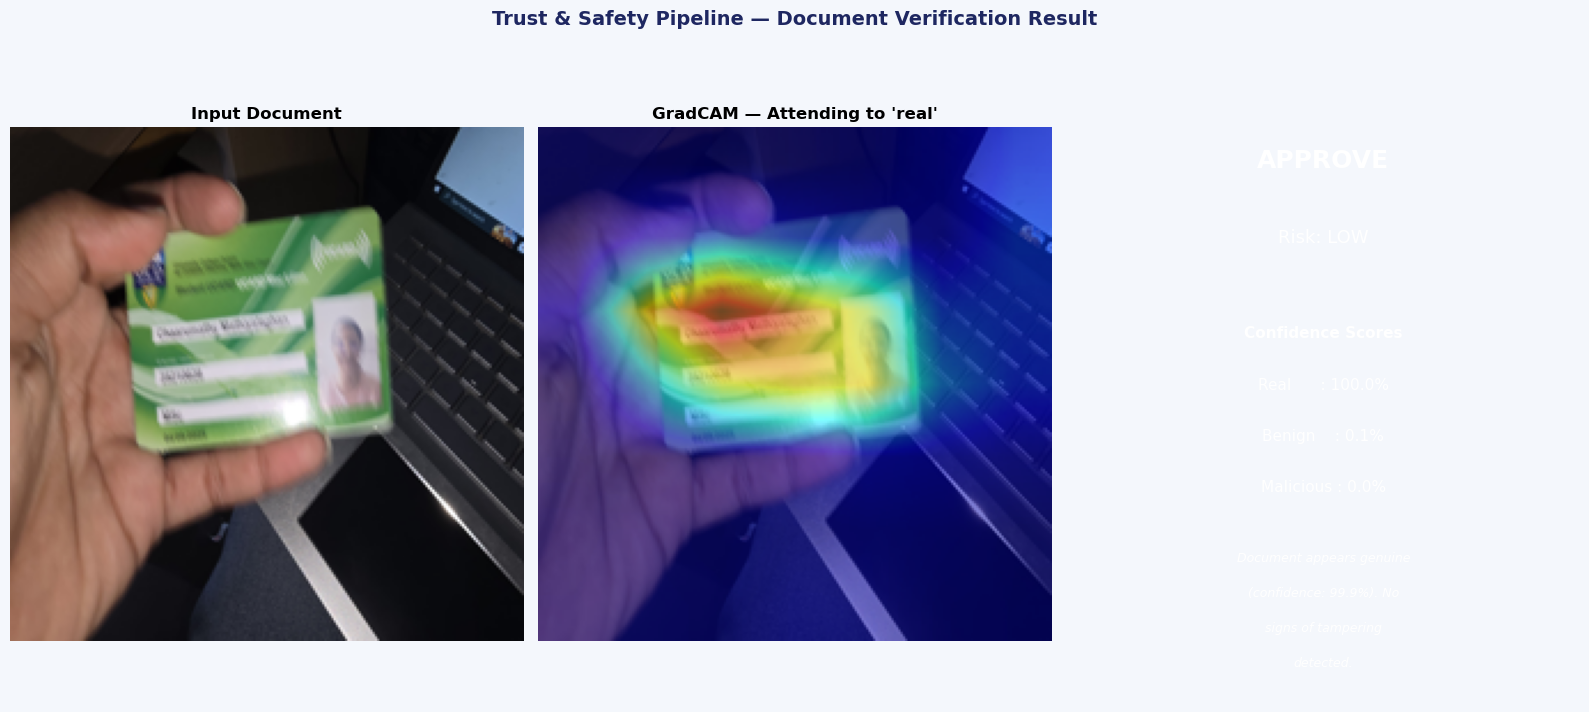


  DECISION   : APPROVE
  RISK LEVEL : LOW
  Predicted  : real
  Real       : 0.9995
  Benign     : 0.0005
  Malicious  : 0.0000
  Reason: Document appears genuine (confidence: 99.9%). No signs of tampering detected.


In [5]:
# Path of the Image
IMAGE_PATH = r"C:/Users/chaar/Chaaru1_card.JPG"

# Run pipeline
result = run_pipeline(IMAGE_PATH)
show_result(result)
